# Lab 6

You are tasked with evaluating card counting strategies for black jack. In order to do so, you will use object oriented programming to create a playable casino style black jack game where a computer dealer plays against $n$ computer players and possibily one human player. If you don't know the rules of blackjack or card counting, please google it. 

A few requirements:
* The game should utilize multiple 52-card decks. Typically the game is played with 6 decks.
* Players should have chips.
* Dealer's actions are predefined by rules of the game (typically hit on 16). 
* The players should be aware of all shown cards so that they can count cards.
* Each player could have a different strategy.
* The system should allow you to play large numbers of games, study the outcomes, and compare average winnings per hand rate for different strategies.

In [23]:
# This cell will contain all imports

import random
import matplotlib.pyplot as plt
import numpy as np

# total code being utilized as an import, used at the very end
# allows the user to compete with the other strategies
# didnt quite get this to work, but ill leave it as is

# For grading purposes, ill leave this commented out
# import Blackjack

1. Begin by creating a classes to represent cards and decks. The deck should support more than one 52-card set. The deck should allow you to shuffle and draw cards. Include a "plastic" card, placed randomly in the deck. Later, when the plastic card is dealt, shuffle the cards before the next deal.

In [7]:
# ------------------------------------------------------#
#                     Card class                        #
# This class is used to represent a single playing card #
# ------------------------------------------------------#

class Card:
    # The following are the attributes of the playing card, this defines the rank & suit as well as the plastic card

    # These are the class variables that are shared by all card instances, not necessarily stored per card
    # every card within the deck uses the same possible ranks & suits, so theres no reason to copy these lists on each obj
    ranks = ['2', '3', '4', '5', '6', '7', '8', '9', '10', 'Jack', 'Queen', 'King', 'Ace']
    suits = ['Hearts', 'Diamonds', 'Clubs', 'Spades']
    # plastic attribute in init

    def __init__(self, rank, suit, plastic=False):
        # the rank will appear as one of the strings within the ranks list
        self.rank = rank
        # the suit will appear as one of the strings within the suits list
        self.suit = suit
        # This value will be true only for the special card, and false for all real cards
        # with the default being false, that means that the normal Card (rank, suit) calls
        # do not need to mention it , only the one plastic card is ever set as true
        self.plastic = plastic

    def val(self):
        # This function will return the numeric value of the card,
        # i.e. face cards have a val of 10 and an ace can be 1 or 11
        # depending on what is at play

        # First and foremost, the plastic card, it is not a real card and
        # has no game value, so its value is 0
        if self.plastic:
            return 0

        # Face cards, this is the Jack, Queen, and King. In bj they are 10.
        if self.rank in ('Jack', 'Queen', 'King'):
            return 10

        # Ace is 11 by default, unless the value exceeds 21, then the hand will
        # reduce its value to 1 as needed
        if self.rank == 'Ace':
            return 11

        # The number cards will simply be their respective val, the only note is that
        # as these are stored as strings in a list, they must be converted to an integer val
        return int(self.rank)

    def __repr__(self):
        # As introduced ~lecture 10, the repr function is a dunder method to represent an
        # unambiguous string representation of an object
        # This will control what we see when printing a card, w/o this we would see the address (if I understand this right)
    
        # The plastic card will have its own identification as it will cause a reshuffle, this makes it
        # obvious once it appears
        if self.plastic:
            return '[Plastic]'
    
        # As for the rest of the cards, they will be displayed as their "rank" of "suit", King of
        # Hearts for example.
        return f'{self.rank} of {self.suit}'
    
# -------------------------------------------------------#
#                      Deck class                        #
# represents the decks in blackjack, this class handles  #
# multiple dekcs being present as is standard with       #
# most casinos, winstar is 6 so we will use 6 decks here #
# -------------------------------------------------------#
class Deck:
    def __init__(self, n_decks=6):
        # n_decks is the number of decks, it will dictate how many 52-card decks will be combined. Local casinos all use 6,
        # as this is the standard in Oklahoma I believe.
        self.n_decks = n_decks

        # This concerns the reshuffle, whenever the plastic card is drawn this value will become true and call for a reshuffle
        # Base value is false, deck creation will not call for a 'reshuffle'
        self.reshuffle = False

        # This will call for the build and shuffle of the deck. In blackjack, the term may also be called 'washing the deck', this
        # method is used to maximize randomness of decks within a 'shoe', useful when cards are considered 'sticky' from a previous
        # play or when dishing out a new deck
        self.wash()

    # it is not something i am going to implement here, but I saw that a convention for internal code can use _ in front of some functions
    # to indicate if that is internal code endemic to the class. If you read this and that is the case, I can implement that in future
    # functions to show that. Ex: def _wash(self):
    
    def wash(self):
        # This function will build the card list using a list comprehension. Nested loops are utilized to create one card per
        # rank & suit combination. This will be repreated n_decks times, in this case it is 6 x 52 = 312 cards total.
        self.cards = [
        Card(rank, suit)
        for i in range(self.n_decks) # repreat each deck
        for suit in Card.suits # iterate over all 4 suits
        for rank in Card.ranks # iterate over all 13 ranks
        ]

        # shuffle the list, this will randomize the order of all 312 cards.
        random.shuffle(self.cards)

        # Insert the plastic card, in context this is the cut card that determines the shuffle point, but i will continue to refer
        # to it as the plastic card. The cut card will be at a random position in the middle third of the entire shoe. Ideally, the shoe will
        # be between 33% and 66% used before triggering a reshuffle.
        total = len(self.cards)
        plastic_cutcard = random.randint(total // 3, 2 * total // 3)
        self.cards.insert (plastic_cutcard, Card('Plastic', 'Plastic', plastic=True))

        # reset plastic back to false after the shoe is rebuilt after a reshuffle
        self.reshuffle = False

    # just calls back to wash for shuffling
    def shuffle(self):
        self.wash()

    def draw(self):
        # This function calls and returns the top card from the shoe, in context this means that it is pulling the last item from the
        # list and treating this as teh top of the deck. the list.pop() python utility removes and returns the last element.

        if not self.cards:
            self.wash()

        # remove and return last card in list, in other words, the top of the deck
        card = self.cards.pop()

        # If the plastic card is drawn, set the reshuffle flag to true and draw the actual card sitting behind it. The plastic card is never
        # returned, it is only a marker
        if card.plastic:
            self.reshuffle = True

            # safety net if plastic is very last item
            if not self.cards:
                self.wash()

            # draw real card sitting behind plastic marker
            card = self.cards.pop()
        return card
    
    def cards_left(self):
        # returns how many cards are left in the shoe
        return len(self.cards)

    def __repr__(self):
        # as before, this is an f string giving a readable summary of the deck obj
        return f'Deck({self.n_decks} decks, {self.cards_left()} cards remaining)'

In [8]:
# Test the Cards and Decks classes

d = Deck(n_decks=6)
print(d)

sample = [d.draw() for _ in range(5)]
print('First 5 cards:', sample)
print('Card values:  ', [c.val() for c in sample])  # note: value() with parentheses
print('Reshuffle needed?', d.reshuffle)

Deck(6 decks, 313 cards remaining)
First 5 cards: [Queen of Diamonds, King of Clubs, 6 of Clubs, 9 of Diamonds, 8 of Hearts]
Card values:   [10, 10, 6, 9, 8]
Reshuffle needed? False


2. Now design your game on a UML diagram. You may want to create classes to represent, players, a hand, and/or the game. As you work through the lab, update your UML diagram. At the end of the lab, submit your diagram (as pdf file) along with your notebook. 

In [ ]:
# There will be an attatched pdf within the lab 6 folder for the UML diagram

3. Begin with implementing the skeleton (ie define data members and methods/functions, but do not code the logic) of the classes in your UML diagram.

In [9]:
# This is the skeleton of the other classes within the program
# As required by this question and what is sensible, we need a class to represent Players, Hand, Game, and potentially the Dealer
# Separating the Player and Dealer makes sense sinice they will have different properties for chips and bets
# Additionally, there will be subclasses to the Player class that will implement different strategies, but that will come later

# Adjustment to the statement above, I actually will implement Dealer a subclass to the Player class for simplicity

#---------------------------------------------------#
#                   Hand Class                      #
# The set of cards held by one player or the dealer #
# during a single round. Responsible for knowing    #
# its own total value & whether it has bust         #
#---------------------------------------------------#

class Hand:
    def __init__(self):
        # cards: the list of card obj currently in hand
        self.cards = []

    def hit(self, card):
        # adds a card to the hand, functions as a "hit"
        pass

    def val(self):
        # this will return the best total to not bust, in context of the aces
        # Ace is 11, but if the value exceeds 21, it is 1
        pass

    def bust(self):
        # self explanatory, this function will return true if the val exceeds 21
        pass

    def blackjack(self):
        # returns true if exactly 2 cards total to 21
        pass

    def clear(self):
        # empties hand between round, hence the name
        pass

    def __repr__(self):
        # as before, this is the printed result
        pass

#------------------------------------------------------------------#
#                    Player class                                  #
# This is the base class, and subclasses will be implemented later #
#------------------------------------------------------------------#

class Player:
    def __init__(self, name, chips=500):
        #rather than going by chip type, for the sake of this lab, we will simply refer to the chips total monetary value
        self.name = name
        self.chips = chips
        self.hand = Hand()
        self.bet = 0

    def place_bet(self, cards_viewed):
        pass

    def choice(self, dealer_up, cards_viewed):
        # in this context, dealer_up refers to the card from the dealer that is visible
        # this function is the one allowing for the choice between hit or stand
        pass

    def receive(self, card):
        # this adds the dealt card to the hand
        pass

    def __repr__(self):
        pass

# -------------------------------------------------------#
#                   Dealer class                         #
# Subclass of Player, same structure, fixed decisions    #
# -------------------------------------------------------#

class Dealer(Player):

    def __init__(self):
        # Calls Player.__init__ for hand setup
        # No chips or real bet needed
        super().__init__(name='Dealer', chips=0)
        # The above function w/ super() is utilized to access properties from a parent or sibling class
        # In this case, the dealer class is accessing properties form the Player class
        # As expected, the dealer chips will be 0 because the dealer does not play

    def choice(self, dealer_up, cards_viewed):
        # Hit on 16 or under, stand on 17+
        # Ignores cards_viewed and dealer_up entirely
        pass

    def up_card(self):
        # Returns the face-up card that the players can see
        pass

# -------------------------------------------------------#
#                   Game class                           #
# This is the class concerning game functionality        #
# -------------------------------------------------------#

# For the below function, ChatGPT had implemented verbose=true, this essentially
# adds a dialogue to view

class Game:

    def __init__(self, players, n_decks=6, verbose=True):
        self.players = players
        self.deck = Deck(n_decks)
        self.dealer = Dealer()
        self.seen_cards = []      # all face-up cards this shoe
        self.verbose = verbose

    # --- Public ------------------------------------------
    # The only method that should ever be called from outside

    def play_round(self):
        # Runs one full round start to finish
        # Internally calls all the private methods below in order
        pass

    # --- Private ------------------------------------------
    # Only play_round() should ever call these

    def __deal_initial(self):
        # Deals opening two cards to all players and the dealer
        pass

    def __player_turn(self, player):
        # Manages one player hitting or standing until their turn ends
        pass

    def __dealer_turn(self):
        # Reveals the hole card then hits until the dealer must stand
        pass

    def __settle_bets(self):
        # Compares each player's hand to the dealer and moves chips
        pass

    def __notify_seen(self, card):
        # Records a face-up card to seen_cards so counters can read it
        pass

# The other subclasses for player will be implemented below as they are presented, the above code is the essential skeleton

4. Complete the implementation by coding the logic of all functions. For now, just implement the dealer player and human player.

In [10]:
#---------------------------------------------------#
#                   Hand Class                      #
# The set of cards held by one player or the dealer #
# during a single round. Responsible for knowing    #
# its own total value & whether it has bust         #
#---------------------------------------------------#

class Hand:
    def __init__(self):
        # cards: the list of card obj currently in hand
        self.cards = []

    def hit(self, card):
        # adds a card to the hand, functions as a "hit"
        self.cards.append(card)

    def val(self):
        # This computes the best total value iwhout busting, start by summing all card values
        # using the val() method from the class Card
        total = sum(card.val() for card in self.cards)

        # As outlined by the skeleton prior, count aces in hand and determine whther the value
        # shall represent 11 as it does by default, or if we need to shrink it to 1. We do this
        # ace by ace until we are under 21 or every ace has been reduced.
        aces = sum(1 for card in self.cards if card.rank == 'Ace')

        # subtract by 10 to reduce ace to 1
        while total > 21 and aces:
            total -= 10
            aces -= 1

        return total
            

    def bust(self):
        # self explanatory, this function will return true if the val exceeds 21
        return self.val() > 21

    def blackjack(self):
        # returns true if exactly 2 cards total to 21
        # fir further clarification, a 21 from 3 cards would not qualify
        return len(self.cards) == 2 and self.val() == 21

    def clear(self):
        # empties hand between round, hence the name
        self.cards = []

    def __repr__(self):
        # as before, this is the printed result
        return f'{self.cards} = {self.val()}'

#------------------------------------------------------------------#
#                    Player class                                  #
# This is the base class, and subclasses will be implemented later #
#------------------------------------------------------------------#

class Player:
    def __init__(self, name, chips=500):
        #rather than going by chip type, for the sake of this lab, we will simply refer to the chips total monetary value
        self.name = name
        self.chips = chips
        self.hand = Hand()
        self.bet = 0

    def place_bet(self, cards_viewed):
        return min(10, self.chips)
        # Base class just returns a flat default bet & subclasses will override this with different logic,
        # we use min() so a player cannot bet more than they currently have

    def choice(self, dealer_up, cards_viewed):
        # in this context, dealer_up refers to the card from the dealer that is visible
        # this function is the one allowing for the choice between hit or stand
        return 'stand'
        # For this instance, the player will always stand by default, subclasses with strategies will differ

    def receive(self, card):
        # this adds the dealt card to the hand
        self.hand.hit(card)

    def __repr__(self):
        return f'{self.name} (${self.chips})'
        # displays $

# -------------------------------------------------------#
#                   Dealer class                         #
# Subclass of Player, same structure, fixed decisions    #
# -------------------------------------------------------#

class Dealer(Player):

    def __init__(self):
        # Calls Player.__init__ for hand setup
        # No chips or real bet needed
        super().__init__(name='Dealer', chips=0)
        # The above function w/ super() is utilized to access properties from a parent or sibling class
        # In this case, the dealer class is accessing properties form the Player class
        # As expected, the dealer chips will be 0 because the dealer does not play

    def choice(self, dealer_up, cards_viewed):
        # Hit on 16 or under, stand on 17+
        # Ignores cards_viewed and dealer_up entirely
        if self.hand.val() <= 16:
            return 'hit'
        return 'stand'
        # above is standard dealers rule

    def up_card(self):
        # Returns the face-up card that the players can see
        if self.hand.cards:
            return self.hand.cards[0]
        return None
        # the first card dealt to dealer is the face up card, and it will
        # return None if no cards have yet been dealt, safety check

#-------------------------------------------------------# 
#                  Human Player                         #
# This is the subclass of player for an interactive     #
# human at the table, interactions come from user input #
#-------------------------------------------------------#

class HumanPlayer(Player):

    def __init__(self, name, chips=500):
        # Pass straight up to Player's __init__
        super().__init__(name, chips)
        # same super() as seen before, functionality detailed in other functions

    def place_bet(self, cards_viewed):
        # Ask the user how much they want to bet
        # Keep asking until they give a valid number
        while True:
            try:
                amount = int(input(f'{self.name} (${self.chips}) — enter bet: $'))
                if 1 <= amount <= self.chips:
                    return amount
                # If the number is valid but out of range, explain why
                print(f'  Bet must be between $1 and ${self.chips}')
            except ValueError:
                # If they typed something that isn't a number at all
                print('  Please enter a number')
        # TryExccept for error checking

    def choice(self, dealer_up, cards_viewed):
        # Show the player what they're working with, then ask hit or stand
        print(f'  Your hand : {self.hand}')
        print(f'  Dealer shows : {dealer_up}')
        while True:
            action = input('  Hit or stand? (h/s): ').strip().lower()
            if action in ('h', 'hit'):
                return 'hit'
            if action in ('s', 'stand'):
                return 'stand'
            print('  Please enter h or s')
        # TryExcept for error checking

# -------------------------------------------------------#
#                   Game class                           #
# This is the class concerning game functionality        #
# -------------------------------------------------------#

# As initially laid out in the skeleton, ChatGPT had recommended to utilize verbose=true
        
class Game:

    def __init__(self, players, n_decks=6, verbose=True):
        self.players = players

        # creates the shoe using the Deck class, n_decks defaults to 6 as that is
        # the casino standard
        self.deck = Deck(n_decks)

        # one dealer per game, created automatically
        self.dealer = Dealer()

        # cards_viewed is the running list of all face-up cards seen this shoe,
        # players with counting strategies will read this list to make decisions
        self.cards_viewed = []

        # verbose controls whether the game prints commentary, useful to turn off
        # when running large simulations in later exercises
        self.verbose = verbose

        # tracks which round we are on, starts at 0 and increments each round
        self.round_num = 0
        # this was not included in the skeleton, but it made sense to add it in hindsight

    # gpt addition below
    def __log(self, message):
        # this is the central print gate, every message in the game goes through here
        # if verbose is false, nothing prints at all, keeping simulations clean
        if self.verbose:
            print(message)
        # for future runs where we are only concerned with stats, verbose being able to be
        # set to false is very useful

    # --- Public -------------------------------------------
    # play_round is the only method that should be called from outside the class

    def play_round(self):
        self.round_num += 1
        self.__log(f'\n{"-"*40}')
        self.__log(f'  ROUND {self.round_num}')
        self.__log(f'{"-"*40}')

        # only players who still have chips are allowed to play this round
        active = [p for p in self.players if p.chips > 0]
        if not active:
            self.__log('All players are out of chips.')
            return

        # step 1 — collect bets from all active players
        # chips are deducted here and added back later on a win or push
        for player in active:
            player.bet = player.place_bet(self.cards_viewed)
            player.chips -= player.bet
            self.__log(f'  {player.name} bets ${player.bet}  (${player.chips} remaining)')

        # step 2 — deal the opening two cards to everyone
        self.__deal_initial(active)

        # step 3 — each player takes their turn one at a time
        for player in active:
            self.__log(f'\n  {player.name}\'s turn:')
            self.__player_turn(player)

        # step 4 — dealer takes their turn after all players are done
        self.__log(f'\n  Dealer\'s turn:')
        self.__dealer_turn()

        # step 5 — compare all hands to the dealer and move chips accordingly
        self.__log(f'\n  Results:')
        self.__settle_bets(active)

        # step 6 — clear all hands so everyone starts fresh next round
        self.dealer.hand.clear()
        for player in active:
            player.hand.clear()

        # step 7 — if the plastic card was drawn this round, reshuffle the shoe
        # and reset cards_viewed since th count no longer applies to a new shoe
        if self.deck.reshuffle:
            self.__log('  [Plastic card reached — reshuffling the shoe]')
            self.deck.wash()
            self.cards_viewed = []

    # --- Private ----------------------------------------
    # everything below is internal, only play_round should call these

    def __deal_initial(self, active):
        # this follows the standard casino deal order, one card to each player
        # left to right, then the dealer, then a second card to each player,
        # then the dealers hole card

        # first card to every player, face up so it goes into cards_viewed
        for player in active:
            self.__deal_card(player, face_up=True)

        # dealers first card, this is the up card that everyone can see
        self.__deal_card(self.dealer, face_up=True)

        # second card to every player, also face up
        for player in active:
            self.__deal_card(player, face_up=True)

        # dealers hole card, face down so it does NOT go into cards_viewed yet
        # it gets revealed and recorded later in __dealer_turn
        self.__deal_card(self.dealer, face_up=False)

        self.__log(f'  Dealer shows : {self.dealer.up_card()}')
        for player in active:
            self.__log(f'  {player.name} hand : {player.hand}')

    def __deal_card(self, recipient, face_up=True):
        # draws a card from the shoe and gives it to whoever needs it,
        # this is a helper used by __deal_initial and __player_turn so the
        # draw-and-notify logic only has to live in one place
        card = self.deck.draw()
        recipient.receive(card)

        # only face up cards get added to cards_viewed, the hole card skips this
        if face_up:
            self.__notify_viewed(card)

        return card

    def __player_turn(self, player):
        # keeps asking the player to hit or stand until they bust,
        # get blackjack, or choose to stand
        while True:
            if player.hand.blackjack():
                self.__log(f'  {player.name} has blackjack')
                break
            if player.hand.bust():
                self.__log(f'  {player.name} busts with {player.hand}')
                break

            # pass cards_viewed so counting strategies can use it
            action = player.choice(self.dealer.up_card(), self.cards_viewed)

            if action == 'hit':
                card = self.__deal_card(player, face_up=True)
                self.__log(f'  {player.name} hits -> {card}   hand : {player.hand}')
            else:
                self.__log(f'  {player.name} stands with {player.hand}')
                break

    def __dealer_turn(self):
        # the hole card is now revealed, so we add it to cards_viewed here
        # this is the point where card counters learn what the dealer was hiding
        hole = self.dealer.hand.cards[1]
        self.__notify_viewed(hole)
        self.__log(f'  Dealer reveals hole card : {hole}   hand : {self.dealer.hand}')

        # dealer hits until their own choice() method says stand
        while self.dealer.choice(None, self.cards_viewed) == 'hit':
            card = self.__deal_card(self.dealer, face_up=True)
            self.__log(f'  Dealer hits -> {card}   hand : {self.dealer.hand}')

        if self.dealer.hand.bust():
            self.__log(f'  Dealer busts with {self.dealer.hand}')
        else:
            self.__log(f'  Dealer stands with {self.dealer.hand}')

    def __settle_bets(self, active):
        # compares each players hand to the dealers and moves chips accordingly
        # the bet was already subtracted when it was placed, so returning bet * 2
        # means giving back the original stake plus an equal profit,
        # returning just bet is a push where you get your money back but nothing extra,
        # and returning 0 means the bet is simply gone
        d_val = self.dealer.hand.val()
        d_bust = self.dealer.hand.bust()
        d_bj = self.dealer.hand.blackjack()

        for player in active:
            p_val = player.hand.val()
            p_bust = player.hand.bust()
            p_bj = player.hand.blackjack()
            bet = player.bet

            if p_bust:
                # player busted, bet is already gone
                result = 0
                outcome = 'Busts — loses'

            elif p_bj and d_bj:
                # both have blackjack, this is a push so the bet is returned
                result = bet
                outcome = 'Blackjack push — bet returned'

            elif p_bj:
                # player has blackjack and dealer does not, pays out 3:2
                result = bet + int(bet * 1.5)
                outcome = 'BLACKJACK — wins 3:2'

            elif d_bust:
                # dealer busted and player did not, player wins even money
                result = bet * 2
                outcome = 'Dealer busts — wins'

            elif p_val > d_val:
                # player beats dealer, wins even money
                result = bet * 2
                outcome = f'{p_val} vs {d_val} — wins'

            elif p_val == d_val:
                # tie, push, bet is returned
                result = bet
                outcome = f'{p_val} vs {d_val} — push'

            else:
                # dealer wins, bet is gone
                result = 0
                outcome = f'{p_val} vs {d_val} — loses'

            player.chips += result
            net = result - bet
            self.__log(f'  {player.name}: {outcome}  (${net:+})  chips=${player.chips}')

    def __notify_viewed(self, card):
        # adds a face up card to the cards_viewed list, any player using a
        # counting strategy will read this list when making their decisions
        self.cards_viewed.append(card)

In [24]:
#NOTE: Exercise 5 is the implementation of DealerStrategyPlayer, which I use here
#      Run the exercise 5 cell to do the human vs dealerstrategyplayer test

# As the next function calls for testing a subclass of player, this test will address the human player subclass

# -------------------------------------------------------#
#               Human Player Test                        #
# -------------------------------------------------------#

# create one human player and two computer players
players = [
    HumanPlayer('Human1', chips=500),
    DealerStrategyPlayer('Bot1', chips=500),
    DealerStrategyPlayer('Bot2',   chips=500),
    ]

# verbose=True so we can see everything happening
game = Game(players, n_decks=6, verbose=True)

# just one round so the input prompts don't get overwhelming
game.play_round()

# show final chips after the round
print('\nChip counts after round:')
for p in players:
    print(f'  {p.name}: ${p.chips}')


----------------------------------------
  ROUND 1
----------------------------------------


Human1 ($500) — enter bet: $ 500


  Human1 bets $500  ($0 remaining)
  Bot1 bets $10  ($490 remaining)
  Bot2 bets $10  ($490 remaining)
  Dealer shows : 3 of Clubs
  Human1 hand : [7 of Spades, King of Diamonds] = 17
  Bot1 hand : [King of Spades, 4 of Clubs] = 14
  Bot2 hand : [Ace of Diamonds, 2 of Diamonds] = 13

  Human1's turn:
  Your hand : [7 of Spades, King of Diamonds] = 17
  Dealer shows : 3 of Clubs


  Hit or stand? (h/s):  s


  Human1 stands with [7 of Spades, King of Diamonds] = 17

  Bot1's turn:
  Bot1 hits -> 10 of Clubs   hand : [King of Spades, 4 of Clubs, 10 of Clubs] = 24
  Bot1 busts with [King of Spades, 4 of Clubs, 10 of Clubs] = 24

  Bot2's turn:
  Bot2 hits -> 7 of Hearts   hand : [Ace of Diamonds, 2 of Diamonds, 7 of Hearts] = 20
  Bot2 stands with [Ace of Diamonds, 2 of Diamonds, 7 of Hearts] = 20

  Dealer's turn:
  Dealer reveals hole card : 5 of Diamonds   hand : [3 of Clubs, 5 of Diamonds] = 8
  Dealer hits -> 8 of Clubs   hand : [3 of Clubs, 5 of Diamonds, 8 of Clubs] = 16
  Dealer hits -> King of Spades   hand : [3 of Clubs, 5 of Diamonds, 8 of Clubs, King of Spades] = 26
  Dealer busts with [3 of Clubs, 5 of Diamonds, 8 of Clubs, King of Spades] = 26

  Results:
  Human1: Dealer busts — wins  ($+500)  chips=$1000
  Bot1: Busts — loses  ($-10)  chips=$490
  Bot2: Dealer busts — wins  ($+10)  chips=$510

Chip counts after round:
  Human1: $1000
  Bot1: $490
  Bot2: $510


5.  Test. Demonstrate game play. For example, create a game of several dealer players and show that the game is functional through several rounds.

In [12]:
# I did not implement this above, but the "dealer player" is this
# They play the same way as the dealer
# -------------------------------------------------------#
#                DealerStrategyPlayer                    #
# A computer player that mirrors the dealers strategy,   #
# hit on 16 or under, stand on 17 or over, flat bet      #
# -------------------------------------------------------#

class DealerStrategyPlayer(Player):

    def __init__(self, name, chips=500):
        # passes straight up to Player init, nothing extra needed
        super().__init__(name, chips)

    def place_bet(self, cards_viewed):
        # flat bet every round, never more than what they have
        return min(10, self.chips)

    def choice(self, dealer_up, cards_viewed):
        # mirrors the dealer exactly, hit on 16 or under
        if self.hand.val() <= 16:
            return 'hit'
        return 'stand'

# -------------------------------------------------------#
#              DealerStrategyPlayer Test                 #
# -------------------------------------------------------#

# create four computer players each starting with 500 chips
players = [
    DealerStrategyPlayer('P1', chips=500),
    DealerStrategyPlayer('P2',   chips=500),
    DealerStrategyPlayer('P3', chips=500),
    DealerStrategyPlayer('P4',  chips=500),
]

# create the game with verbose=True so we can watch every action
game = Game(players, n_decks=6, verbose=True)

# play 5 rounds
for _ in range(5):
    game.play_round()

# print final chip counts after all 5 rounds
print('\nFinal chip counts:')
for p in players:
    print(f'  {p.name}: ${p.chips}')


----------------------------------------
  ROUND 1
----------------------------------------
  P1 bets $10  ($490 remaining)
  P2 bets $10  ($490 remaining)
  P3 bets $10  ($490 remaining)
  P4 bets $10  ($490 remaining)
  Dealer shows : 4 of Diamonds
  P1 hand : [7 of Diamonds, Queen of Diamonds] = 17
  P2 hand : [10 of Spades, 4 of Hearts] = 14
  P3 hand : [9 of Clubs, Ace of Clubs] = 20
  P4 hand : [Queen of Diamonds, 5 of Hearts] = 15

  P1's turn:
  P1 stands with [7 of Diamonds, Queen of Diamonds] = 17

  P2's turn:
  P2 hits -> 5 of Spades   hand : [10 of Spades, 4 of Hearts, 5 of Spades] = 19
  P2 stands with [10 of Spades, 4 of Hearts, 5 of Spades] = 19

  P3's turn:
  P3 stands with [9 of Clubs, Ace of Clubs] = 20

  P4's turn:
  P4 hits -> 2 of Hearts   hand : [Queen of Diamonds, 5 of Hearts, 2 of Hearts] = 17
  P4 stands with [Queen of Diamonds, 5 of Hearts, 2 of Hearts] = 17

  Dealer's turn:
  Dealer reveals hole card : 3 of Diamonds   hand : [4 of Diamonds, 3 of Diamonds

6. Implement a new player with the following strategy:

    * Assign each card a value: 
        * Cards 2 to 6 are +1 
        * Cards 7 to 9 are 0 
        * Cards 10 through Ace are -1
    * Compute the sum of the values for all cards seen so far.
    * Hit if sum is very negative, stay if sum is very positive. Select a threshold for hit/stay, e.g. 0 or -2.  

In [14]:
# -------------------------------------------------------#
#                   HiLoPlayer                           #
# This player uses the Hi-Lo card counting strategy,     #
# tracking the running count of all cards seen so far    #
# to make smarter betting and hit/stand decisions        #
# -------------------------------------------------------#

class HiLoPlayer(Player):

    def __init__(self, name, chips=500, threshold=0):
        # passes name and chips up to Player init as usual
        super().__init__(name, chips)

        # threshold is the count value that determines hit vs stand
        # if the running count is at or above this num, stand
        # if it is below, hit. 0 is the threshhold value we will use here
        self.threshold = threshold

    def __running_count(self, cards_viewed):
        # computes the Hi-Lo running count from all cards seen so far
        # this is the core of the counting strategy —
        # low cards (2-6) leaving the deck is good for the player because it means more high cards
        # remain, so we count them as +1 high cards (10-A) leaving is bad for the player, so they are -1
        # neutral cards (7-9) do not affect the count
        count = 0
        for card in cards_viewed:
            if 2 <= card.val() <= 6:
                count += 1    # low card seen, deck is getting better
            elif card.val() >= 10:
                count -= 1    # high card seen, deck is getting weaker
            # 7, 8, 9 add nothing to the count
        return count

    def place_bet(self, cards_viewed):
        # bet more when the count is positive because the deck is rich
        # in high cards which favors the player, bet the minimum otherwise
        count = self.__running_count(cards_viewed)
        if count >= self.threshold:
            return min(50, self.chips)   # favorable deck, bet big
        return min(10, self.chips)       # unfavorable deck, bet small
        # an important distinction to make here vs other strategies, others just bet small
        # w/ 10, whereas here there are variable bets

    def choice(self, dealer_up, cards_viewed):
        # always stand on 17 or above regardless of the count,
        # this is the same hard floor the dealer uses and is just
        # sensible play no matter what the count says
        if self.hand.val() >= 17:
            return 'stand'

        # below 17, let the count decide a high positive count means lots of face cards remain in the shoe,
        # which means hitting is risky since we are likely to bust,
        # so we stand when the count is at or above the threshold
        # a negative count means lots of low cards remain, so hitting is
        # safer and we are more likely to improve our hand
        count = self.__running_count(cards_viewed)
        if count >= self.threshold:
            return 'stand'
        return 'hit'

In [25]:
# -------------------------------------------------------#
#              HiLoPlayer Test                           #
# -------------------------------------------------------#

players = [
    HiLoPlayer('HiLoPlayer', chips=500, threshold=0),
    DealerStrategyPlayer('P2',   chips=500),
    DealerStrategyPlayer('P3',     chips=500),
]

game = Game(players, n_decks=6, verbose=True)

for _ in range(3):
    game.play_round()

print('\nFinal chip counts:')
for p in players:
    print(f'  {p.name}: ${p.chips}')


----------------------------------------
  ROUND 1
----------------------------------------
  HiLoPlayer bets $50  ($450 remaining)
  P2 bets $10  ($490 remaining)
  P3 bets $10  ($490 remaining)
  Dealer shows : 4 of Hearts
  HiLoPlayer hand : [5 of Diamonds, 5 of Clubs] = 10
  P2 hand : [6 of Spades, 6 of Spades] = 12
  P3 hand : [King of Clubs, 2 of Clubs] = 12

  HiLoPlayer's turn:
  HiLoPlayer stands with [5 of Diamonds, 5 of Clubs] = 10

  P2's turn:
  P2 hits -> 3 of Diamonds   hand : [6 of Spades, 6 of Spades, 3 of Diamonds] = 15
  P2 hits -> King of Clubs   hand : [6 of Spades, 6 of Spades, 3 of Diamonds, King of Clubs] = 25
  P2 busts with [6 of Spades, 6 of Spades, 3 of Diamonds, King of Clubs] = 25

  P3's turn:
  P3 hits -> 6 of Diamonds   hand : [King of Clubs, 2 of Clubs, 6 of Diamonds] = 18
  P3 stands with [King of Clubs, 2 of Clubs, 6 of Diamonds] = 18

  Dealer's turn:
  Dealer reveals hole card : King of Hearts   hand : [4 of Hearts, King of Hearts] = 14
  Dealer h

7. Create a test scenario where one player, using the above strategy, is playing with a dealer and 3 other players that follow the dealer's strategy. Each player starts with same number of chips. Play 50 rounds (or until the strategy player is out of money). Compute the strategy player's winnings. You may remove unnecessary printouts from your code (perhaps implement a verbose/quiet mode) to reduce the output.

HiLo Results
Rounds played       : 50
Final chips         : $425
Net winnings        : $-75
Average per round   : $-1.50


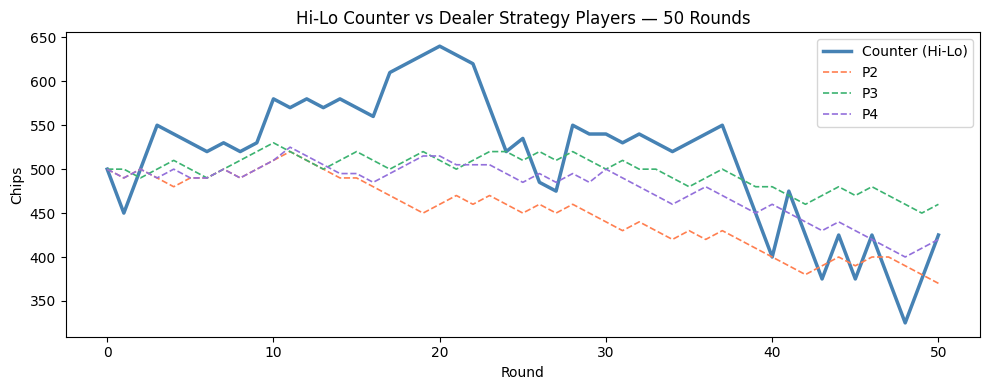

In [16]:
# -------------------------------------------------------#
#               Hilo vs Dealer Strategies                #
# One HiLoPlayer against a dealer and 3 computer players #
# Each starts with 500 chips, play up to 50 rounds or    #
# until the counter runs out of chips                    #
# -------------------------------------------------------#

starting_chips = 500

# create the Hi-Lo counter and three computer opponents
counter = HiLoPlayer('HiLoPlayer', chips=starting_chips, threshold=0)
opponents = [
    DealerStrategyPlayer('P2', chips=starting_chips),
    DealerStrategyPlayer('P3',   chips=starting_chips),
    DealerStrategyPlayer('P4', chips=starting_chips),
]

# verbose=False here because 50 rounds of printed output would be very long, we only care about the chip totals at the end
game = Game([counter] + opponents, n_decks=6, verbose=False)

# track chip history for every player after each round so we can
# compare how the counter performed against the basic strategy players
chip_history = {
    counter.name : [starting_chips],
    opponents[0].name : [starting_chips],
    opponents[1].name : [starting_chips],
    opponents[2].name : [starting_chips],
}

for r in range(50):
    # stop early if the counter goes broke
    if counter.chips <= 0:
        print(f'Counter went broke at round {r}!')
        break
    game.play_round()

    # record each players chip count after this round
    chip_history[counter.name].append(counter.chips)
    for opponent in opponents:
        chip_history[opponent.name].append(opponent.chips)

# calculate results for the counter
rounds_played = len(chip_history[counter.name]) - 1
net = counter.chips - starting_chips
avg_per_round = net / rounds_played if rounds_played > 0 else 0

print(f'HiLo Results')
print(f'Rounds played       : {rounds_played}')
print(f'Final chips         : ${counter.chips}')
print(f'Net winnings        : ${net:+}')
print(f'Average per round   : ${avg_per_round:+.2f}')

# plot all four players chip histories on the same chart so we can visually compare the counter against the dealer strategy players
plt.figure(figsize=(10, 4))

# counter gets a bolder line so it stands out from the opponents
plt.plot(chip_history[counter.name], color='steelblue',
         linewidth=2.5, label='Counter (Hi-Lo)')

# each opponent gets their own color
colors = ['coral', 'mediumseagreen', 'mediumpurple']
for opponent, color in zip(opponents, colors):
    plt.plot(chip_history[opponent.name], color=color,
             linewidth=1.2, linestyle='--', label=opponent.name)

plt.xlabel('Round')
plt.ylabel('Chips')
plt.title('Hi-Lo Counter vs Dealer Strategy Players — 50 Rounds')
plt.legend()
plt.tight_layout()
plt.show()

# After a few different runs, HiLo appears to have a stronger tendency to lose,
# though it has an observed higher peak than the dealer strategy players. IF
# the threshold is adjusted, perhaps the hilo strategy player can have better results.

8. Create a loop that runs 100 games of 50 rounds, as setup in previous question, and store the strategy player's chips at the end of the game (aka "winnings") in a list. Histogram the winnings. What is the average winnings per round? What is the standard deviation. What is the probabilty of net winning or lossing after 50 rounds?


╔══════════════════════════════════════╗
║     Hi-Lo Results — 100 Games        ║
╠══════════════════════════════════════╣
║  Mean net winnings    : $-223.30
║  Standard deviation   : $234.12
║  Averageg per round   : $-4.47
╠══════════════════════════════════════╣
║  Prob(net win)        : 19%
║  Porb(net loss)       : 80%
║  Prob(exactly even)   : 1%
╚══════════════════════════════════════╝


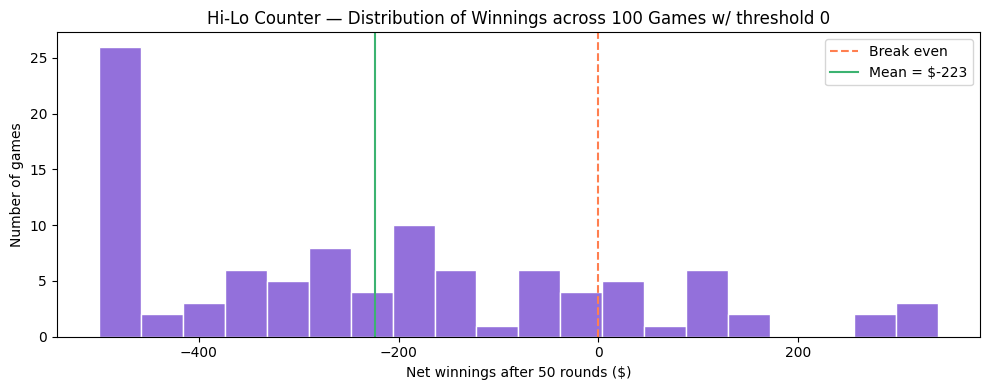

In [17]:
# -------------------------------------------------------#
#            Hilo Probabilities                          #
# Run 100 games of 50 rounds each, record the counters   #
# final chips after each game, then analyze the results  #
# -------------------------------------------------------#

starting_chips = 500
n_games = 100
n_rounds = 50

# this list will store the counter's final chip count after each game
final_chips = []

for game_num in range(n_games):
    # recreate all players fresh for every game so nothing carries over
    # from the previous game, each game needs to be fully independent
    counter = HiLoPlayer('HiLoPlayer', chips=starting_chips, threshold=0)
    opponents = [
        DealerStrategyPlayer('P2', chips=starting_chips),
        DealerStrategyPlayer('P3', chips=starting_chips),
        DealerStrategyPlayer('P4', chips=starting_chips),
        ]

    game = Game([counter] + opponents, n_decks=6, verbose=False)

    for r in range(n_rounds):
        # stop early if the counter goes broke
        if counter.chips <= 0:
            break
        game.play_round()

    # record where the counter ended up after this game
    final_chips.append(counter.chips)

# convert final chips to net winnings by subtracting what everyone started with
net_winnings = [chips - starting_chips for chips in final_chips]

# calculate statistics
mean_net    = np.mean(net_winnings)
std_net     = np.std(net_winnings)
avg_per_rnd = mean_net / n_rounds

# probability is just counting how many games ended above or below zero
p_win  = sum(1 for w in net_winnings if w > 0) / n_games
p_loss = sum(1 for w in net_winnings if w < 0) / n_games
p_push = sum(1 for w in net_winnings if w == 0) / n_games

# I had ChatGPT generate a format for a nicer text output
# frankly ive got no idea how to use these characters, but the appearance is better
print(f'╔══════════════════════════════════════╗')
print(f'║     Hi-Lo Results — {n_games} Games        ║')
print(f'╠══════════════════════════════════════╣')
print(f'║  Mean net winnings    : ${mean_net:+.2f}')
print(f'║  Standard deviation   : ${std_net:.2f}')
print(f'║  Averageg per round   : ${avg_per_rnd:+.2f}')
print(f'╠══════════════════════════════════════╣')
print(f'║  Prob(net win)        : {p_win:.0%}')
print(f'║  Porb(net loss)       : {p_loss:.0%}')
print(f'║  Prob(exactly even)   : {p_push:.0%}')
print(f'╚══════════════════════════════════════╝')

# histogram of the net winnings across all 100 games
plt.figure(figsize=(10, 4))
plt.hist(net_winnings, bins=20, color='mediumpurple', edgecolor='white')
plt.axvline(0,        color='coral',        linestyle='--', label='Break even')
plt.axvline(mean_net, color='mediumseagreen', linestyle='-',  label=f'Mean = ${mean_net:+.0f}')
plt.xlabel('Net winnings after 50 rounds ($)')
plt.ylabel('Number of games')
plt.title('Hi-Lo Counter — Distribution of Winnings across 100 Games w/ threshold 0')
plt.legend()
plt.tight_layout()
plt.show()

# The spread seems consistent with a pattern that was visbile when running exercise 8
# there is a 3/4 chance of losing and only a 1/4 chance of winning with the
# HiLo strategy

# Though potential winnings with the HiLo can exceed the dealer strategy, there is a
# greater potential for loss with this strategy. Perhaps changing the
# threshold value can yield different results

9. Repeat previous questions scanning the value of the threshold. Try at least 5 different threshold values. Can you find an optimal value?

╔══════════════════════════════════════╗
║     Threshold = -4                    ║
╠══════════════════════════════════════╣
║  Mean net winnings    : $-251.15
║  Standard deviation   : $239.07
║  Average per round    : $-5.02
╠══════════════════════════════════════╣
║  Prob(net win)        : 15%
║  Porb(net loss)       : 85%
╚══════════════════════════════════════╝

╔══════════════════════════════════════╗
║     Threshold = -2                    ║
╠══════════════════════════════════════╣
║  Mean net winnings    : $-216.35
║  Standard deviation   : $217.64
║  Average per round    : $-4.33
╠══════════════════════════════════════╣
║  Prob(net win)        : 18%
║  Porb(net loss)       : 82%
╚══════════════════════════════════════╝

╔══════════════════════════════════════╗
║     Threshold = +0                    ║
╠══════════════════════════════════════╣
║  Mean net winnings    : $-218.10
║  Standard deviation   : $262.47
║  Average per round    : $-4.36
╠═══════════════════════════════════

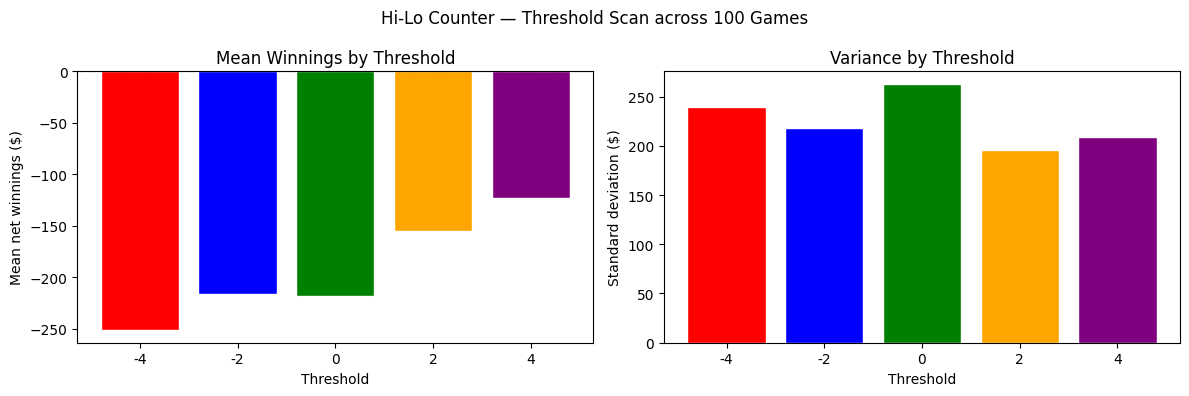

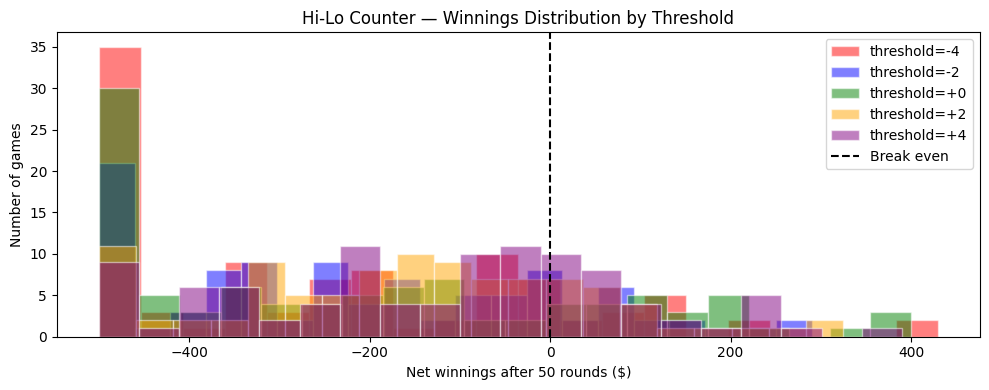

In [18]:
# -------------------------------------------------------#
#                   Exercise 9                           #
# Scan at least 5 threshold values and compare the       #
# counter's average winnings per round for each one      #
# to try and find the optimal threshold setting          #
# -------------------------------------------------------#

# the thresholds we want to test, negative means hit more aggressively,
# positive means stand more conservatively
thresholds = [-4, -2, 0, 2, 4]

# store results for each threshold so we can compare them
results = {}

for t in thresholds:
    final_chips = []

    for game_num in range(n_games):
        # recreate players fresh for every game as before
        counter = HiLoPlayer('HiLoPlayer', chips=starting_chips, threshold=t)
        opponents = [
            DealerStrategyPlayer('P2', chips=starting_chips),
            DealerStrategyPlayer('P3', chips=starting_chips),
            DealerStrategyPlayer('P4', chips=starting_chips),
        ]

        game = Game([counter] + opponents, n_decks=6, verbose=False)

        for r in range(n_rounds):
            if counter.chips <= 0:
                break
            game.play_round()

        final_chips.append(counter.chips)

    # calculate stats for this threshold
    net_winnings    = [chips - starting_chips for chips in final_chips]
    mean_net        = np.mean(net_winnings)
    std_net         = np.std(net_winnings)
    avg_per_rnd     = mean_net / n_rounds
    p_win           = sum(1 for w in net_winnings if w > 0) / n_games
    p_loss          = sum(1 for w in net_winnings if w < 0) / n_games

    results[t] = {
        'mean_net'    : mean_net,
        'std_net'     : std_net,
        'avg_per_rnd' : avg_per_rnd,
        'p_win'       : p_win,
        'p_loss'      : p_loss,
        'net_winnings': net_winnings,
    }

    print(f'╔══════════════════════════════════════╗')
    print(f'║     Threshold = {t:+d}                    ║')
    print(f'╠══════════════════════════════════════╣')
    print(f'║  Mean net winnings    : ${mean_net:+.2f}')
    print(f'║  Standard deviation   : ${std_net:.2f}')
    print(f'║  Average per round    : ${avg_per_rnd:+.2f}')
    print(f'╠══════════════════════════════════════╣')
    print(f'║  Prob(net win)        : {p_win:.0%}')
    print(f'║  Porb(net loss)       : {p_loss:.0%}')
    print(f'╚══════════════════════════════════════╝')
    print()

# find the best threshold by highest mean net winnings
best_threshold = max(results, key=lambda t: results[t]['mean_net'])
print(f'Best threshold: {best_threshold:+d}  '
      f'(mean net = ${results[best_threshold]["mean_net"]:+.2f})')

# basic colors, one per threshold so they are easy to tell apart
colors = ['red', 'blue', 'green', 'orange', 'purple']

# Plot 1 - mean net winnings and variance per threshold

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

mean_vals = [results[t]['mean_net'] for t in thresholds]
std_vals  = [results[t]['std_net']  for t in thresholds]

axes[0].bar([str(t) for t in thresholds], mean_vals,
            color=colors, edgecolor='white')
axes[0].axhline(0, color='black', linestyle='--')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Mean net winnings ($)')
axes[0].set_title('Mean Winnings by Threshold')

axes[1].bar([str(t) for t in thresholds], std_vals,
            color=colors, edgecolor='white')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Standard deviation ($)')
axes[1].set_title('Variance by Threshold')

plt.suptitle('Hi-Lo Counter — Threshold Scan across 100 Games')
plt.tight_layout()
plt.show()

# Plot 2 - overlapping histograms for each threshold

plt.figure(figsize=(10, 4))
for t, color in zip(thresholds, colors):
    plt.hist(results[t]['net_winnings'], bins=20, alpha=0.5,
             color=color, edgecolor='white', label=f'threshold={t:+d}')
plt.axvline(0, color='black', linestyle='--', label='Break even')
plt.xlabel('Net winnings after 50 rounds ($)')
plt.ylabel('Number of games')
plt.title('Hi-Lo Counter — Winnings Distribution by Threshold')
plt.legend()
plt.tight_layout()
plt.show()

10. Create a new strategy based on web searches or your own ideas. Demonstrate that the new strategy will result in increased or decreased winnings. 

In [19]:
# https://youtu.be/HeVclniKpHs?si=HfYVmppjkXRsoHTQ
# This is the "perfect basic" strategy

# ---------------------------------------------------------#
#                  Perfect Basic                           #
# A new player implementing perfect basic strategy         #
# combined with Hi-Lo bet spreading from exercise 6        #
# Basic strategy is the "mathematically optimal" hit/stand #
# decision for every hand total vs dealer up card          #
# ---------------------------------------------------------#

class BasicStrategyPlayer(Player):

    def __init__(self, name, chips=500):
        super().__init__(name, chips)

    def __running_count(self, cards_viewed):
        # this is the same Hi-Lo running count from exercise 6,
        # the only difference here is that we use it purely for
        # bet sizing rather than hit/stand decisions, since basic
        # strategy handles those decisions on its own through the
        # lookup tables in __hard_strategy and __soft_strategy
        count = 0
        for card in cards_viewed:
            if 2 <= card.val() <= 6:
                # low card just left the deck, meaning the remaining shoe has a slightly higher ratio of high cards,
                # which is favorable for the player
                count += 1
            elif card.val() >= 10:
                # high card just left the deck, meaning the remainin gshoe is getting weaker
                count -= 1
        return count

    def place_bet(self, cards_viewed):
        # unlike the HiLoPlayer in exercise 6 which only had two bet
        # sizes, this player uses three tiers based on the running count
        # this more closely mirrors how real card counters actually
        # size their bets in practice, scaling up gradually as the
        # deck becomes more favorable rather than jumping straight
        # from minimum to maximum
        count = self.__running_count(cards_viewed)
        if count >= 2:
            return min(50, self.chips)   # very favorable deck, bet big
        elif count >= 0:
            return min(25, self.chips)   # slightly favorable, bet medium
        return min(10, self.chips)       # unfavorable deck, bet small

    def __is_soft(self):
        # a soft hand is one where an ace is being counted as 11 rather than 1, meaning the hand has flexibility since
        # the ace can flip down to 1 if needed to avoid busting we detect this by checking two conditions simultaneously:
        # first that the hand actually contains an ace, and second that the current total is 21 or under meaning the ace
        # is still contributing 11 rather than having already been reduced to 1 by the val() method in the Hand class
        total_with_ace_high = sum(card.val() for card in self.hand.cards)
        has_ace = any(card.rank == 'Ace' for card in self.hand.cards)
        return has_ace and total_with_ace_high <= 21

    def __hard_strategy(self, total, dealer_val):
        # this is the perfect basic strategy lookup table for hard totals a hard total is any hand without an ace, or one where the ace
        # is already being counted as 1 to avoid busting every decision here is "mathematically optimal" meaning no other
        # choice produces a better expected outcome over the long run
        # https://www.blackjackapprenticeship.com/blackjack-strategy-charts/

        # always stand on hard 17 or above, hitting risks busting with
        # no realistic chance of improving enough to matter
        if total >= 17:
            return 'stand'

        # always hit on 8 or below, you cannot bust and need to improve
        if total <= 8:
            return 'hit'

        # hard 9 — basic strategy says double vs 3-6, otherwise hit
        # since we have no doubling, we hit in all cases
        if total == 9:
            return 'hit'

        # hard 10 — double vs 2-9, hit vs 10 or ace
        # since we have no doubling, hit in all cases
        if total == 10:
            return 'hit'

        # hard 11 — double vs everything except ace, hit vs ace
        # since we have no doubling, hit in all cases
        if total == 11:
            return 'hit'

        # hard 12 — stand vs dealer 4-6 (dealer likely to bust),
        # hit vs everything else
        if total == 12:
            return 'stand' if 4 <= dealer_val <= 6 else 'hit'

        # hard 13-16 — stand vs dealer 2-6 (weak dealer), hit vs 7+
        # the logic here is that a dealer showing 2-6 must hit and is
        # statistically likely to bust, so we do not risk busting for ourselves
        if 13 <= total <= 16:
            return 'stand' if dealer_val <= 6 else 'hit'

        return 'hit'

    def __soft_strategy(self, total, dealer_val):
        # perfect basic strategy for soft totals
        # soft hands are more flexible because the ace can flip to 1

        # soft 19 or above — always stand, already a strong hand
        if total >= 19:
            return 'stand'

            # apparently soft 18 is the most nuanced decision in all of basic strategy vs dealer 9, 10, or ace we hit because the dealer likely
            # already has us beaten or close to it, and since we cannot bust on a soft hand we should try to improve
            # vs dealer 2, 7, or 8 we stand since 18 is a strong enough total that we are likely already ahead or tied
            # basic strategy actually says to double vs dealer 3-6 here
            # but since we have no doubling implemented we stand instead
            # which is the next best play in that situation
        if total == 18:
            if dealer_val in (9, 10, 11):
                return 'hit'
            return 'stand'

        # soft 17 or below — always hit, the hand is too weak to stand
        # and we cannot bust since the ace will just flip to 1
        return 'hit'

    def choice(self, dealer_up, cards_viewed):
        total = self.hand.val()

        # get the dealer's up card value, default to 10 if somehow None
        # cap at 10 since J, Q, K all count as 10 for strategy purposes
        dealer_val = dealer_up.val() if dealer_up else 10

        # route to the correct strategy table based on hand type
        if self.__is_soft():
            return self.__soft_strategy(total, dealer_val)
        return self.__hard_strategy(total, dealer_val)

╔══════════════════════════════════════╗
║         Hi-Lo Strategy               ║
╠══════════════════════════════════════╣
║  Mean net winnings    : $-175.70
║  Standard deviation   : $214.70
║  Average per round        : $-3.51
╠══════════════════════════════════════╣
║  Prob(net win)           : 19%
║  Prob(net loss)          : 81%
╚══════════════════════════════════════╝

╔══════════════════════════════════════╗
║       Basic Strategy + Hi-Lo Bets    ║
╠══════════════════════════════════════╣
║  Mean net winnings    : $-52.27
║  Standard deviation   : $223.85
║  Average per round        : $-1.05
╠══════════════════════════════════════╣
║  Prob(net win)           : 42%
║  Prob(net loss)          : 57%
╚══════════════════════════════════════╝


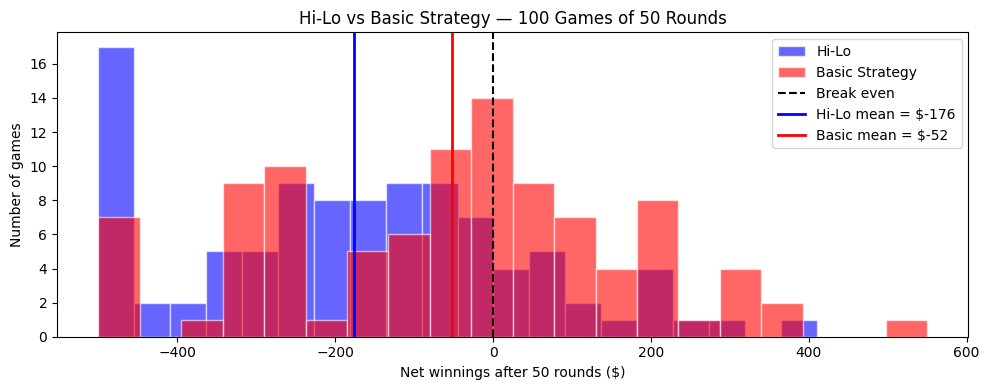

In [20]:
# -------------------------------------------------------#
#          Comparison Test - HiLo vs Basic               #
# Run 100 games for both strategies and compare results  #
# -------------------------------------------------------#

final_chips_hilo  = []
final_chips_basic = []

for game_num in range(n_games):
    # hi lo
    counter_hilo = HiLoPlayer('HiLoPlayer', chips=starting_chips, threshold=0)
    opponents_hilo = [
        DealerStrategyPlayer('P2', chips=starting_chips),
        DealerStrategyPlayer('P3', chips=starting_chips),
        DealerStrategyPlayer('P4', chips=starting_chips),
    ]
    game_hilo = Game([counter_hilo] + opponents_hilo, n_decks=6, verbose=False)

    for r in range(n_rounds):
        if counter_hilo.chips <= 0:
            break
        game_hilo.play_round()

    final_chips_hilo.append(counter_hilo.chips)

    # basic strategy
    counter_basic = BasicStrategyPlayer('BasicPlayer', chips=starting_chips)
    opponents_basic = [
        DealerStrategyPlayer('P2', chips=starting_chips),
        DealerStrategyPlayer('P3', chips=starting_chips),
        DealerStrategyPlayer('P4', chips=starting_chips),
    ]
    game_basic = Game([counter_basic] + opponents_basic, n_decks=6, verbose=False)

    for r in range(n_rounds):
        if counter_basic.chips <= 0:
            break
        game_basic.play_round()

    final_chips_basic.append(counter_basic.chips)

# calculate net winnings for both strategies
net_hilo  = [chips - starting_chips for chips in final_chips_hilo]
net_basic = [chips - starting_chips for chips in final_chips_basic]

# print comparisons

print(f'╔══════════════════════════════════════╗')
print(f'║         Hi-Lo Strategy               ║')
print(f'╠══════════════════════════════════════╣')
print(f'║  Mean net winnings    : ${np.mean(net_hilo):+.2f}')
print(f'║  Standard deviation   : ${np.std(net_hilo):.2f}')
print(f'║  Average per round        : ${np.mean(net_hilo)/n_rounds:+.2f}')
print(f'╠══════════════════════════════════════╣')
print(f'║  Prob(net win)           : {sum(1 for w in net_hilo if w > 0)/n_games:.0%}')
print(f'║  Prob(net loss)          : {sum(1 for w in net_hilo if w < 0)/n_games:.0%}')
print(f'╚══════════════════════════════════════╝')
print()
print(f'╔══════════════════════════════════════╗')
print(f'║       Basic Strategy + Hi-Lo Bets    ║')
print(f'╠══════════════════════════════════════╣')
print(f'║  Mean net winnings    : ${np.mean(net_basic):+.2f}')
print(f'║  Standard deviation   : ${np.std(net_basic):.2f}')
print(f'║  Average per round        : ${np.mean(net_basic)/n_rounds:+.2f}')
print(f'╠══════════════════════════════════════╣')
print(f'║  Prob(net win)           : {sum(1 for w in net_basic if w > 0)/n_games:.0%}')
print(f'║  Prob(net loss)          : {sum(1 for w in net_basic if w < 0)/n_games:.0%}')
print(f'╚══════════════════════════════════════╝')

# ── Plot ──────────────────────────────────────────────────

plt.figure(figsize=(10, 4))
plt.hist(net_hilo,  bins=20, alpha=0.6, color='blue',   edgecolor='white', label='Hi-Lo')
plt.hist(net_basic, bins=20, alpha=0.6, color='red',    edgecolor='white', label='Basic Strategy')
plt.axvline(0,                  color='black', linestyle='--',            label='Break even')
plt.axvline(np.mean(net_hilo),  color='blue',  linestyle='-', linewidth=2, label=f'Hi-Lo mean = ${np.mean(net_hilo):+.0f}')
plt.axvline(np.mean(net_basic), color='red',   linestyle='-', linewidth=2, label=f'Basic mean = ${np.mean(net_basic):+.0f}')
plt.xlabel('Net winnings after 50 rounds ($)')
plt.ylabel('Number of games')
plt.title('Hi-Lo vs Basic Strategy — 100 Games of 50 Rounds')
plt.legend()
plt.tight_layout()
plt.show()

## Full Game Demo — 5 Rounds of Interactive Play

This section combines all of the classes built throughout the lab into a single
playable game. You will be playing as a human player against three computer
opponents who follow the dealer strategy, all managed by the Game class built
in exercise 4.

To play:
- When prompted, enter a number between 1 and your chip total as your bet
- When prompted, enter **h** to hit or **s** to stand
- The game will handle the dealer and computer players automatically
- Results and chip counts will be printed after each round

The game uses 6 decks as is standard in Oklahoma casinos, and the plastic cut
card will trigger a reshuffle somewhere in the middle of the shoe. Verbose mode
is set to True so you can follow every action at the table.

chatgpt generated summary ^

In [21]:
# Did not quite get this fully working with the library, but if you run the other code cells prior to this one,
# it should operate as intended

# -------------------------------------------------------#
#                   Full Game Demo                       #
# 1 human player vs 3 computer opponents, 5 rounds       #
# -------------------------------------------------------#

starting_chips = 500

# one of each strategy at the table
players = [
    HumanPlayer('HumanPlayer',        chips=starting_chips),
    DealerStrategyPlayer('DealerStrat',   chips=starting_chips),
    HiLoPlayer('HiLo',             chips=starting_chips, threshold=0),
    BasicStrategyPlayer('PerfectBasic',    chips=starting_chips),
]

# verbose=True so every action at the table is printed
game = Game(players, n_decks=6, verbose=True)

# play up to 5 rounds, stopping early if the human runs out of chips
for _ in range(5):
    if players[0].chips <= 0:
        print('You are out of chips — game over!')
        break
    game.play_round()

# GPT generated final result
# print a final summary showing each players chip total and net gain or loss
print(f'\n{"─"*40}')
print(f'  FINAL RESULTS')
print(f'{"─"*40}')
for p in players:
    net = p.chips - starting_chips
    print(f'  {p.name:<12} ${p.chips:<6}  (${net:+})')
print(f'{"─"*40}')


----------------------------------------
  ROUND 1
----------------------------------------


HumanPlayer ($500) — enter bet: $ 500


  HumanPlayer bets $500  ($0 remaining)
  DealerStrat bets $10  ($490 remaining)
  HiLo bets $50  ($450 remaining)
  PerfectBasic bets $25  ($475 remaining)
  Dealer shows : 5 of Diamonds
  HumanPlayer hand : [3 of Diamonds, 2 of Spades] = 5
  DealerStrat hand : [Queen of Clubs, 6 of Clubs] = 16
  HiLo hand : [6 of Diamonds, 2 of Clubs] = 8
  PerfectBasic hand : [3 of Hearts, King of Hearts] = 13

  HumanPlayer's turn:
  Your hand : [3 of Diamonds, 2 of Spades] = 5
  Dealer shows : 5 of Diamonds


  Hit or stand? (h/s):  h


  HumanPlayer hits -> 7 of Spades   hand : [3 of Diamonds, 2 of Spades, 7 of Spades] = 12
  Your hand : [3 of Diamonds, 2 of Spades, 7 of Spades] = 12
  Dealer shows : 5 of Diamonds


...

  HumanPlayer bets $2500  ($0 remaining)
  DealerStrat bets $10  ($490 remaining)
  HiLo bets $50  ($375 remaining)
  PerfectBasic bets $50  ($325 remaining)
  Dealer shows : 5 of Clubs
  HumanPlayer hand : [Jack of Spades, 2 of Diamonds] = 12
  DealerStrat hand : [Jack of Hearts, Jack of Clubs] = 20
  HiLo hand : [2 of Clubs, 8 of Clubs] = 10
  PerfectBasic hand : [9 of Spades, Ace of Spades] = 20

  HumanPlayer's turn:
  Your hand : [Jack of Spades, 2 of Diamonds] = 12
  Dealer shows : 5 of Clubs


  Hit or stand? (h/s):  h


  HumanPlayer hits -> 5 of Diamonds   hand : [Jack of Spades, 2 of Diamonds, 5 of Diamonds] = 17
  Your hand : [Jack of Spades, 2 of Diamonds, 5 of Diamonds] = 17
  Dealer shows : 5 of Clubs


  Hit or stand? (h/s):  s


  HumanPlayer stands with [Jack of Spades, 2 of Diamonds, 5 of Diamonds] = 17

  DealerStrat's turn:
  DealerStrat stands with [Jack of Hearts, Jack of Clubs] = 20

  HiLo's turn:
  HiLo stands with [2 of Clubs, 8 of Clubs] = 10

  PerfectBasic's turn:
  PerfectBasic stands with [9 of Spades, Ace of Spades] = 20

  Dealer's turn:
  Dealer reveals hole card : 6 of Diamonds   hand : [5 of Clubs, 6 of Diamonds] = 11
  Dealer hits -> 4 of Hearts   hand : [5 of Clubs, 6 of Diamonds, 4 of Hearts] = 15
  Dealer hits -> Queen of Spades   hand : [5 of Clubs, 6 of Diamonds, 4 of Hearts, Queen of Spades] = 25
  Dealer busts with [5 of Clubs, 6 of Diamonds, 4 of Hearts, Queen of Spades] = 25

  Results:
  HumanPlayer: Dealer busts — wins  ($+2500)  chips=$5000
  DealerStrat: Dealer busts — wins  ($+10)  chips=$510
  HiLo: Dealer busts — wins  ($+50)  chips=$475
  PerfectBasic: Dealer busts — wins  ($+50)  chips=$425

────────────────────────────────────────
  FINAL RESULTS
────────────────────────